In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"prathampulkeetdtu1","key":"6a59f146a1495ecad2a5d6302b60d823"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:44<00:00, 15.0MB/s]



In [ ]:
# unzip dataset
import zipfile

zip_ref = zipfile.ZipFile('chest-xray-pneumonia.zip', 'r')
zip_ref.extractall()
zip_ref.close()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
train_path = "chest_xray/train"
test_path = "chest_xray/test"
val_path = "chest_xray/val"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [ ]:
base_dir = "chest_xray"

train_path = os.path.join(base_dir, "train")
test_path = os.path.join(base_dir, "test")

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.15
)

test_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

# Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Dense
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 112s 747ms/step - accuracy: 0.8038 - loss: 0.4696 - val_accuracy: 0.8261 - val_loss: 0.3929
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 97s 697ms/step - accuracy: 0.8850 - loss: 0.2696 - val_accuracy: 0.8798 - val_loss: 0.2687
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 96s 692ms/step - accuracy: 0.8994 - loss: 0.2466 - val_accuracy: 0.8760 - val_loss: 0.2581
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 94s 677ms/step - accuracy: 0.9053 - loss: 0.2229 - val_accuracy: 0.8862 - val_loss: 0.2470
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 96s 693ms/step - accuracy: 0.9082 - loss: 0.2285 - val_accuracy: 0.8913 - val_loss: 0.2544
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 98s 705ms/step - accuracy: 0.9082 - loss: 0.2350 - val_accuracy: 0.8708 - val_loss: 0.3060
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 98s 706ms/step - accuracy: 0.9217 - loss: 0.2078 - val_accuracy: 0.9092 - val_loss: 0.2180
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 98s 707ms/step - accuracy: 0.9267 - loss: 

In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

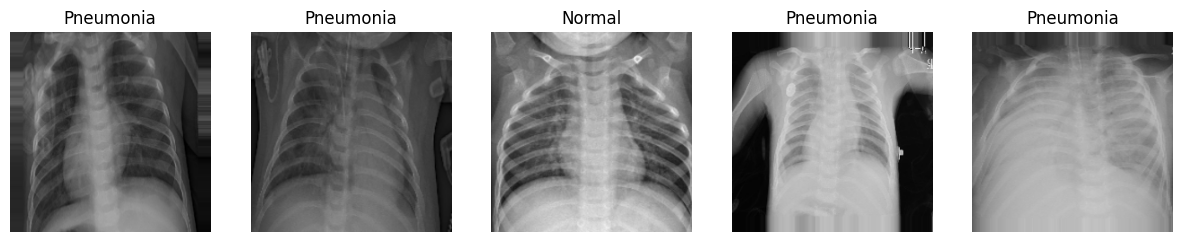

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i]==1 else "Normal")
    plt.axis('off')

plt.show()

In [ ]:
from tensorflow.keras.layers import BatchNormalization

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 4 (NEW)
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Dense
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))

# Output
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,828,033 (37.49 MB)

 Trainable params: 9,827,073 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 111s 745ms/step - accuracy: 0.9041 - loss: 0.3087 - val_accuracy: 0.7430 - val_loss: 7.6378
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 135s 725ms/step - accuracy: 0.9337 - loss: 0.1810 - val_accuracy: 0.7430 - val_loss: 8.2024
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 100s 714ms/step - accuracy: 0.9427 - loss: 0.1527 - val_accuracy: 0.7430 - val_loss: 4.7753
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 98s 707ms/step - accuracy: 0.9520 - loss: 0.1331 - val_accuracy: 0.7494 - val_loss: 1.6891
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 99s 710ms/step - accuracy: 0.9423 - loss: 0.1444 - val_accuracy: 0.8529 - val_loss: 0.3820
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 100s 718ms/step - accuracy: 0.9608 - loss: 0.1137 - val_accuracy: 0.8069 - val_loss: 0.5406
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 100s 719ms/step - accuracy: 0.9587 - loss: 0.1184 - val_accuracy: 0.8555 - val_loss: 0.3240
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 98s 705ms/step - accuracy: 0.9574 - lo

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.15
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
history3 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 100s 720ms/step - accuracy: 0.9671 - loss: 0.0900 - val_accuracy: 0.9578 - val_loss: 0.1138 - learning_rate: 1.0000e-04
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 99s 711ms/step - accuracy: 0.9646 - loss: 0.0921 - val_accuracy: 0.8939 - val_loss: 0.3102 - learning_rate: 1.0000e-04
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 100s 719ms/step - accuracy: 0.9675 - loss: 0.0926 - val_accuracy: 0.9488 - val_loss: 0.1289 - learning_rate: 1.0000e-04
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 99s 711ms/step - accuracy: 0.9725 - loss: 0.0753 - val_accuracy: 0.9757 - val_loss: 0.0551 - learning_rate: 3.0000e-05
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 99s 713ms/step - accuracy: 0.9786 - loss: 0.0644 - val_accuracy: 0.9706 - val_loss: 0.0809 - learning_rate: 3.0000e-05
Epoch 6/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 102s 732ms/step - accuracy: 0.9761 - loss: 0.0635 - val_accuracy: 0.9488 - val_loss: 0.1182 - learning_rate: 3.0000e-05
Epoch 7/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 100

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [ ]:

for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history4 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 130s 843ms/step - accuracy: 0.6946 - loss: 0.6296 - val_accuracy: 0.7430 - val_loss: 0.5626 - learning_rate: 1.0000e-04
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 99s 713ms/step - accuracy: 0.7379 - loss: 0.5766 - val_accuracy: 0.7430 - val_loss: 0.5485 - learning_rate: 1.0000e-04
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 100s 713ms/step - accuracy: 0.7431 - loss: 0.5556 - val_accuracy: 0.7430 - val_loss: 0.5423 - learning_rate: 3.0000e-05


In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history5 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 133s 819ms/step - accuracy: 0.8764 - loss: 0.2809 - val_accuracy: 0.2570 - val_loss: 0.8367 - learning_rate: 1.0000e-05
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 102s 736ms/step - accuracy: 0.9244 - loss: 0.1950 - val_accuracy: 0.9015 - val_loss: 0.2520 - learning_rate: 1.0000e-05
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 105s 750ms/step - accuracy: 0.9411 - loss: 0.1544 - val_accuracy: 0.9194 - val_loss: 0.1804 - learning_rate: 3.0000e-06


In [ ]:
for layer in base_model.layers[-80:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    validation_split=0.15
)

In [ ]:
history6 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=12,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 154s 892ms/step - accuracy: 0.8726 - loss: 0.2997 - val_accuracy: 0.2685 - val_loss: 0.7771 - learning_rate: 5.0000e-06
Epoch 2/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 106s 761ms/step - accuracy: 0.9276 - loss: 0.1936 - val_accuracy: 0.7532 - val_loss: 0.4472 - learning_rate: 5.0000e-06
Epoch 3/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 105s 756ms/step - accuracy: 0.9396 - loss: 0.1525 - val_accuracy: 0.7762 - val_loss: 0.5116 - learning_rate: 1.5000e-06


In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
img_path = "chest_xray/test/PNEUMONIA/person1_virus_6.jpeg"

In [ ]:
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
img_array = np.expand_dims(img, axis=0) / 255.0

In [ ]:
for layer in model.layers:
    print(layer.name)

input_layer_2
conv1_pad
conv1_conv
conv1_bn
conv1_relu
pool1_pad
pool1_pool
conv2_block1_1_conv
conv2_block1_1_bn
conv2_block1_1_relu
conv2_block1_2_conv
conv2_block1_2_bn
conv2_block1_2_relu
conv2_block1_0_conv
conv2_block1_3_conv
conv2_block1_0_bn
conv2_block1_3_bn
conv2_block1_add
conv2_block1_out
conv2_block2_1_conv
conv2_block2_1_bn
conv2_block2_1_relu
conv2_block2_2_conv
conv2_block2_2_bn
conv2_block2_2_relu
conv2_block2_3_conv
conv2_block2_3_bn
conv2_block2_add
conv2_block2_out
conv2_block3_1_conv
conv2_block3_1_bn
conv2_block3_1_relu
conv2_block3_2_conv
conv2_block3_2_bn
conv2_block3_2_relu
conv2_block3_3_conv
conv2_block3_3_bn
conv2_block3_add
conv2_block3_out
conv3_block1_1_conv
conv3_block1_1_bn
conv3_block1_1_relu
conv3_block1_2_conv
conv3_block1_2_bn
conv3_block1_2_relu
conv3_block1_0_conv
conv3_block1_3_conv
conv3_block1_0_bn
conv3_block1_3_bn
conv3_block1_add
conv3_block1_out
conv3_block2_1_conv
conv3_block2_1_bn
conv3_block2_1_relu
conv3_block2_2_conv
conv3_block2_2_bn


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_205']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


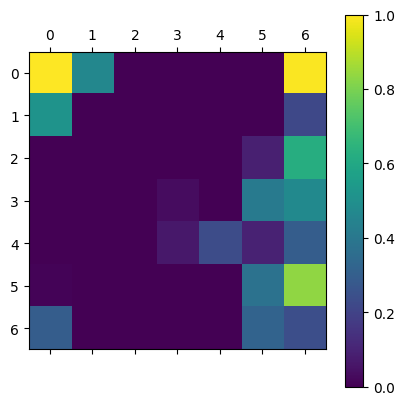

In [ ]:
heatmap = make_gradcam_heatmap(img_array, model, "conv5_block3_out")

plt.matshow(heatmap)
plt.colorbar()
plt.show()

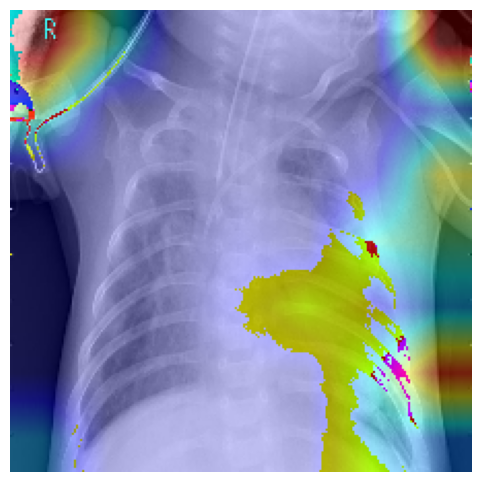

In [ ]:
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
base_dir = "chest_xray"
train_path = os.path.join(base_dir, "train")
test_path = os.path.join(base_dir, "test")

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85,1.15],
    validation_split=0.15
)

test_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,828,033 (37.49 MB)

 Trainable params: 9,827,073 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 118s 800ms/step - accuracy: 0.8834 - loss: 0.3633 - val_accuracy: 0.7430 - val_loss: 4.6264 - learning_rate: 1.0000e-04
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 104s 750ms/step - accuracy: 0.9272 - loss: 0.1856 - val_accuracy: 0.7430 - val_loss: 6.7641 - learning_rate: 1.0000e-04
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 106s 764ms/step - accuracy: 0.9308 - loss: 0.1793 - val_accuracy: 0.7430 - val_loss: 2.9788 - learning_rate: 1.0000e-04
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 112s 808ms/step - accuracy: 0.9438 - loss: 0.1528 - val_accuracy: 0.7481 - val_loss: 1.4361 - learning_rate: 1.0000e-04
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 107s 769ms/step - accuracy: 0.9414 - loss: 0.1549 - val_accuracy: 0.8031 - val_loss: 0.4377 - learning_rate: 1.0000e-04
Epoch 6/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 105s 756ms/step - accuracy: 0.9459 - loss: 0.1373 - val_accuracy: 0.9386 - val_loss: 0.1332 - learning_rate: 1.0000e-04
Epoch 7/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save("/content/drive/MyDrive/pneumonia_cnn1_final.keras")

In [ ]:
!ls /content/drive/MyDrive

 20260121_105423.jpg
 5_6273986585595740537.pdf
'AI HHW.pdf'
 brain_tumor_model.tflite
 brain_tumor_unet.h5
'Brajesh__CV (1).docx'
 Brajesh__CV.docx
 Certificates
'Chapter 11 The Human Eye and the Colourful World-EYE.pdf'
 Classroom
'Colab Notebooks'
 DOC-20220714-WA0000..pdf
 DOC-20220922-WA0011.
'Education for Sustainable Development.pdf'
'Getting started.pdf'
'\.gsheet'
'hhw hindi.docx'
 IMG-20200601-WA0026.jpg
 IMG-20200913-WA0013.jpg
 IMG-20220603-WA0002.jpg
 IMG-20220603-WA0003.jpg
 IMG-20220603-WA0004.jpg
 IMG-20220603-WA0005.jpg
 IMG-20220603-WA0006.jpg
 IMG-20220603-WA0007.jpg
 IMG-20220603-WA0008.jpg
 IMG-20220603-WA0009.jpg
 IMG-20220603-WA0010.jpg
 IMG-20220603-WA0011.jpg
 IMG-20220603-WA0012.jpg
 IMG-20220604-WA0000.jpg
 IMG-20220604-WA0001.jpg
 IMG-20220604-WA0002.jpg
 IMG-20220604-WA0003.jpg
 IMG-20220604-WA0004.jpg
 IMG-20220604-WA0005.jpg
 IMG-20220604-WA0006.jpg
 IMG-20220604-WA0007.jpg
 IMG-20220604-WA0008.jpg
 IMG-20220604-WA0009.jpg
 IMG-20220607-WA0001.jpg
 IMG-20

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Final Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 384ms/step - accuracy: 0.9151 - loss: 0.2289
Final Test Accuracy: 0.9150640964508057


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    "chest_xray/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Final Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 256ms/step - accuracy: 0.9054 - loss: 0.2379
Final Test Accuracy: 0.9054487347602844


In [ ]:
for layer in model.layers:
    print(layer.name)

conv2d_7
batch_normalization_4
max_pooling2d_7
conv2d_8
batch_normalization_5
max_pooling2d_8
conv2d_9
batch_normalization_6
max_pooling2d_9
conv2d_10
batch_normalization_7
max_pooling2d_10
flatten_2
dense_6
dropout_3
dense_7


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
img_path = "chest_xray/test/PNEUMONIA/person1_virus_6.jpeg"

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
img_array = np.expand_dims(img, axis=0) / 255.0

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,482,181 (112.47 MB)

 Trainable params: 9,827,073 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 19,654,148 (74.97 MB)

In [ ]:
# STEP 1 — Load one test image

import os

folder = "chest_xray/test/PNEUMONIA"

# automatically pick first image
img_name = os.listdir(folder)[0]
img_path = os.path.join(folder, img_name)

print("Using image:", img_path)

img = cv2.imread(img_path)

if img is None:
    raise ValueError("Image not loaded. Check dataset path.")

img = cv2.resize(img, (224, 224))

# normalize for model prediction
img_array = np.expand_dims(img, axis=0) / 255.0

Using image: chest_xray/test/PNEUMONIA/person173_bacteria_829.jpeg


In [ ]:
import numpy as np

# force model to build its graph
dummy_input = np.zeros((1, 224, 224, 3), dtype=np.float32)

_ = model.predict(dummy_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.outputs[0]
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        tf.multiply(pooled_grads, conv_outputs),
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
import numpy as np

dummy_input = np.zeros((1, 224, 224, 3), dtype=np.float32)

_ = model.predict(dummy_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [ ]:
import os
import cv2

folder = "chest_xray/test/PNEUMONIA"

img_name = os.listdir(folder)[0]
img_path = os.path.join(folder, img_name)

print("Using image:", img_path)

img = cv2.imread(img_path)

if img is None:
    raise ValueError("Image not loaded. Check path.")

img = cv2.resize(img, (224,224))

img_array = np.expand_dims(img, axis=0) / 255.0

Using image: chest_xray/test/PNEUMONIA/person173_bacteria_829.jpeg


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    last_conv_layer = model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            last_conv_layer.output,
            model.layers[-1].output   # safer than model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        tf.multiply(pooled_grads, conv_outputs),
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
!pip install tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.1 MB/s eta 0:00:00


In [ ]:
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

In [ ]:
folder = "chest_xray/test/PNEUMONIA"

img_name = os.listdir(folder)[0]
img_path = os.path.join(folder, img_name)

print("Using image:", img_path)

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

img_array = np.expand_dims(img, axis=0) / 255.0

Using image: chest_xray/test/PNEUMONIA/person173_bacteria_829.jpeg


In [ ]:
import tensorflow as tf

inputs = tf.keras.Input(shape=(224,224,3))
x = inputs

for layer in model.layers:
    x = layer(x)

functional_model = tf.keras.Model(inputs=inputs, outputs=x)

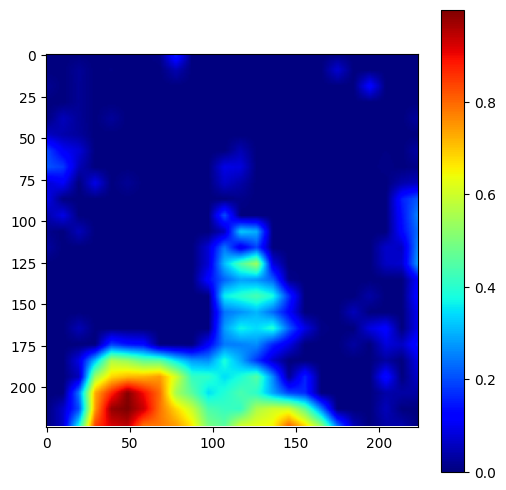

In [ ]:
# Build model once
_ = model(img_array)

# Create GradCAM object
gradcam = Gradcam(
    functional_model,
    model_modifier=ReplaceToLinear(),
    clone=True
)

# Since Pneumonia = class 1
score = BinaryScore(1)

# Generate heatmap
cam = gradcam(score, img_array)

plt.figure(figsize=(6,6))
plt.imshow(cam[0], cmap='jet')
plt.colorbar()
plt.show()

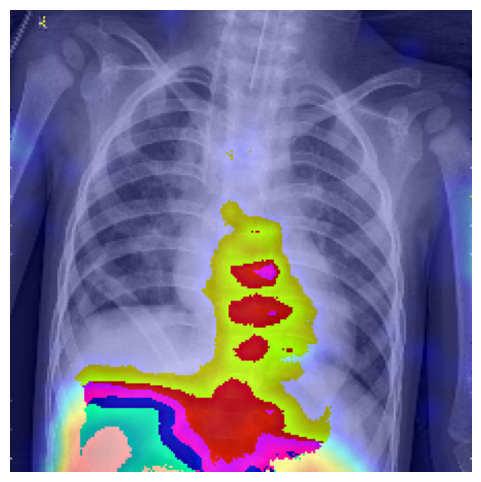

In [ ]:
heatmap = cam[0]

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
model.fit(train_data, epochs=1)

139/139 ━━━━━━━━━━━━━━━━━━━━ 46s 327ms/step - accuracy: 0.9644 - loss: 0.1351


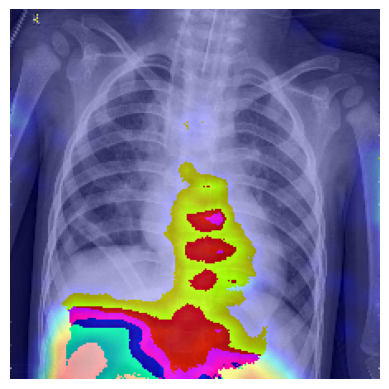

In [ ]:
heatmap = cam[0]

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
model.save("pneumonia_cnn_final.keras")

In [ ]:
from google.colab import files
files.download("pneumonia_cnn_final.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.savefig("gradcam_result.png")

<Figure size 640x480 with 0 Axes>

Grad-CAM image saved successfully!


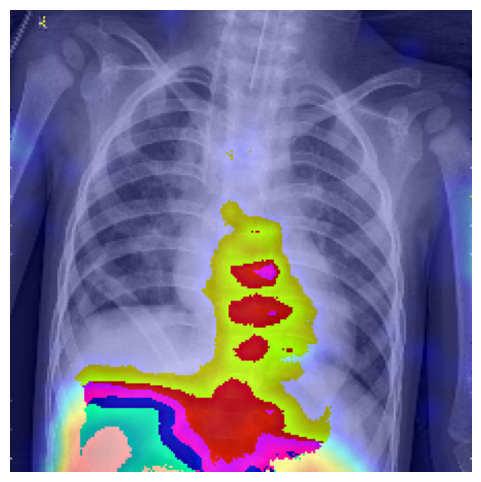

In [ ]:
# Save Grad-CAM overlay image in Colab

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")

# Save image file
plt.savefig("gradcam_result.png", bbox_inches="tight", pad_inches=0)

print("Grad-CAM image saved successfully!")

In [ ]:
# Download the saved image to your laptop

from google.colab import files

files.download("gradcam_result.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>